<a href="https://colab.research.google.com/github/aryaraut13/100-days-of-aiml/blob/main/100daysofAIML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Day 01 — NumPy | 100 Days of AI/ML

import numpy as np

# ── Arrays: the atomic unit of all ML ──────────────────────
arr    = np.array([1, 2, 3, 4, 5])
matrix = np.array([[1, 2, 3],
                   [4, 5, 6]])

print("Shape:", matrix.shape)
print("Reshape →", matrix.reshape(3, 2).shape)

# ── Broadcasting: the magic that replaces loops ─────────────
a = np.array([1, 2, 3])
b = np.array([[10], [20], [30]])

result = a + b
print("\nBroadcast result (3,) + (3,1) → (3,3):")
print(result)
# [[11 12 13]
#  [21 22 23]
#  [31 32 33]]

# ── Why this matters for ML ──────────────────────────────────
data    = np.random.randn(100, 5)
weights = np.random.randn(5, 1)
preds   = data @ weights

print(f"\ndata {data.shape} @ weights {weights.shape} = preds {preds.shape}")
print("↑ This is what every ML model does. Millions of times per second.")

Shape: (2, 3)
Reshape → (3, 2)

Broadcast result (3,) + (3,1) → (3,3):
[[11 12 13]
 [21 22 23]
 [31 32 33]]

data (100, 5) @ weights (5, 1) = preds (100, 1)
↑ This is what every ML model does. Millions of times per second.


In [ ]:
# Day 02 — Pandas | 100 Days of AI/ML
# github.com/aryaraut13/100-days-of-aiml
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")

print("Shape:", df.shape)
print("\nNull counts:")
print(df.isnull().sum())
# Age      177
# Cabin    687
# Embarked   2

df["Age"].fillna(df["Age"].median(), inplace=True)
df.dropna(subset=["Embarked"], inplace=True)
df.drop(columns=["Cabin"], inplace=True)

print("\nAfter cleaning — nulls remaining:", df.isnull().sum().sum())

survival = df.groupby("Pclass")["Survived"].mean().round(2)
print("\nSurvival rate by class:")
print(survival)

print("\n→ Replace Pclass with pricing tier.")
print("→ Replace Survived with converted.")
print("→ Same code. Any business dataset. Real decisions.")

Shape: (891, 12)

Null counts:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

After cleaning — nulls remaining: 0

Survival rate by class:
Pclass
1    0.63
2    0.47
3    0.24
Name: Survived, dtype: float64

→ Replace Pclass with pricing tier.
→ Replace Survived with converted.
→ Same code. Any business dataset. Real decisions.


/tmp/ipykernel_8202/2910877011.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)


/tmp/ipykernel_2150/1032453350.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)


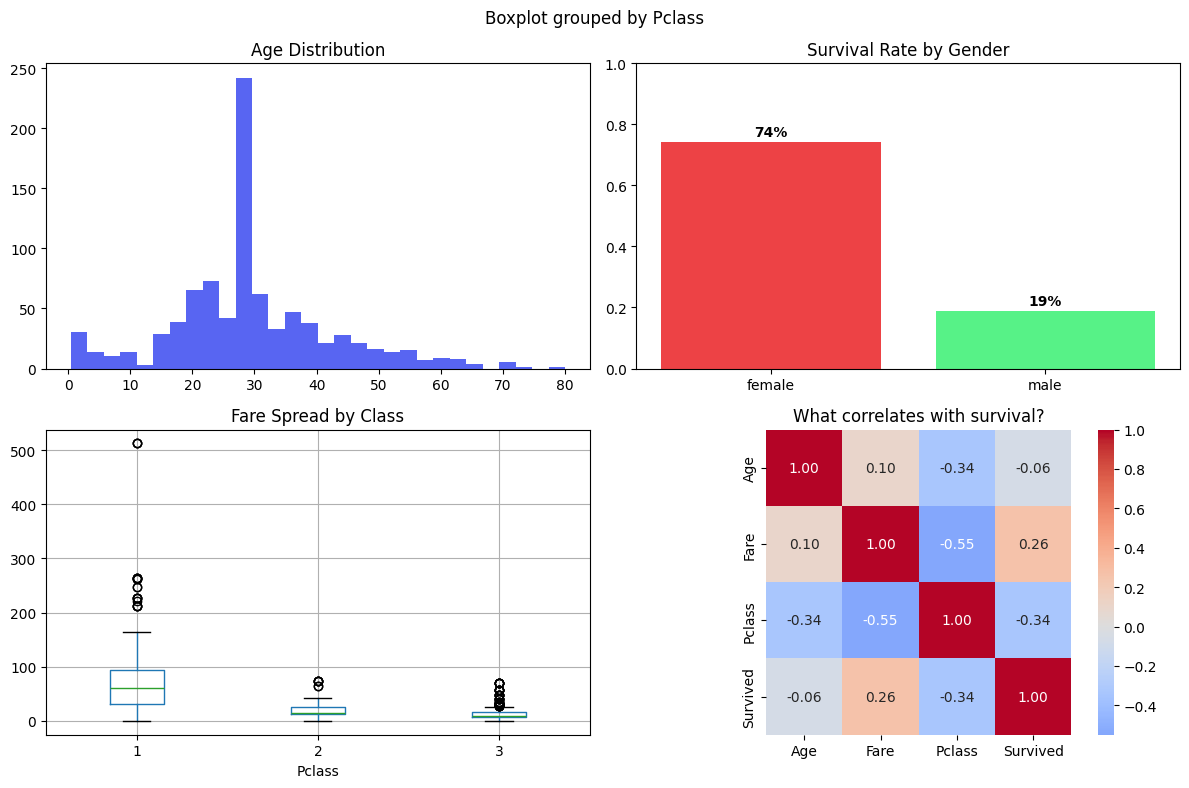

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df["Age"].fillna(df["Age"].median(), inplace=True)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("4 Charts. 10 Minutes. Full Picture.", fontsize=15, fontweight="bold")

axes[0,0].hist(df["Age"].dropna(), bins=30, color="#5865F2", edgecolor="none")
axes[0,0].set_title("Age Distribution")

gender_survival = df.groupby("Sex")["Survived"].mean()
bars = axes[0,1].bar(gender_survival.index, gender_survival.values,
                     color=["#ED4245","#57F287"], edgecolor="none")
axes[0,1].set_title("Survival Rate by Gender")
axes[0,1].set_ylim(0, 1)
for bar, val in zip(bars, gender_survival.values):
    axes[0,1].text(bar.get_x()+bar.get_width()/2, val+0.02,
                   f"{val:.0%}", ha="center", fontweight="bold")

df.boxplot(column="Fare", by="Pclass", ax=axes[1,0])
axes[1,0].set_title("Fare Spread by Class")

corr = df[["Age","Fare","Pclass","Survived"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=axes[1,1], square=True)
axes[1,1].set_title("What correlates with survival?")

plt.tight_layout()
plt.savefig("day03_eda.png", dpi=150, bbox_inches="tight")
plt.show()